## ElasticNet
ElasticNet 算法简单来说就是岭回归和Lasso的简单杂合体（也就是说学习此算法，要先学岭回归和Lasso）

引入它的原因就是我们分析实际问题后，发现我们同时需要目标算法具有岭回归和Lasso两种算法的优点
> Ridge (L2正则化): 处理共线性
>
> Lasso (L1正则化): 特征选择

其损失函数（忽略偏置）如下：
$$
J(w) = (\frac{1}{2n} || y - X w ||^2 + \alpha \cdot \rho \cdot \sum_j|w_j| + \alpha \frac{1 - \rho}{2} \sum_j w_j^2)
$$

结合我们对岭回归和 Lasso 的了解，这只是将两算法的正则化项简单的配以一个权重参数 $ \rho $ 以供调整，其取值范围在区间 $[0, 1]$ 之间，我们可以通过调整其取值来调整算法到底更像谁

而 $\alpha$ 自然也和另外二者一样是用来调整正则化强度的

不难看出 **$\rho$ 和 $\alpha$ 基本会决定我们对于特定数据集训练所得模型的最终情况**，因此这两个参数是我们需要特别关注的主要调整的对象

问题：

为了和岭回归和 Lasso 进行比较，我们仍然使用 sklearn 中内置的diabetes数据集

In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNetCV

### **1.导入并观察数据集的基本情况**

In [4]:
diabetes = load_diabetes()
print(diabetes['DESCR'])
df = pd.DataFrame(diabetes.data, columns = diabetes.feature_names)
print(df)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

### **2.划分训练集和验证集**

In [5]:
X = diabetes.data
y = diabetes.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

### **3.数据进行标准化处理**
既然岭回归和 Lasso 都需要标准化，那么二者复合而成的 ElasticNet 自然也需要

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### **4.训练模型并进行预测**

In [7]:
modelCV = ElasticNetCV(
        alphas = np.logspace(-3, 1, 50),     # 候选 alpha
        l1_ratio = [.1, .3, .5, .7, .9, 1],  # 候选混合比例
        cv = 5,
        n_jobs = -1
        )
modelCV.fit(X_train, y_train)
y_pred = modelCV.predict(X_test)

### **5.对结果进行评估**

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}  (越小越好)")
print(f"RMSE: {rmse:.2f}  (越小越好，和 y 同单位)")
print(f"MAE:  {mae:.2f}  (越小越好，对异常值不敏感)")
print(f"R²:   {r2:.3f}  (越接近 1 越好)")

MSE: 3435.90  (越小越好)
RMSE: 58.62  (越小越好，和 y 同单位)
MAE:  46.16  (越小越好，对异常值不敏感)
R²:   0.330  (越接近 1 越好)


### **6.预测结果可视化**

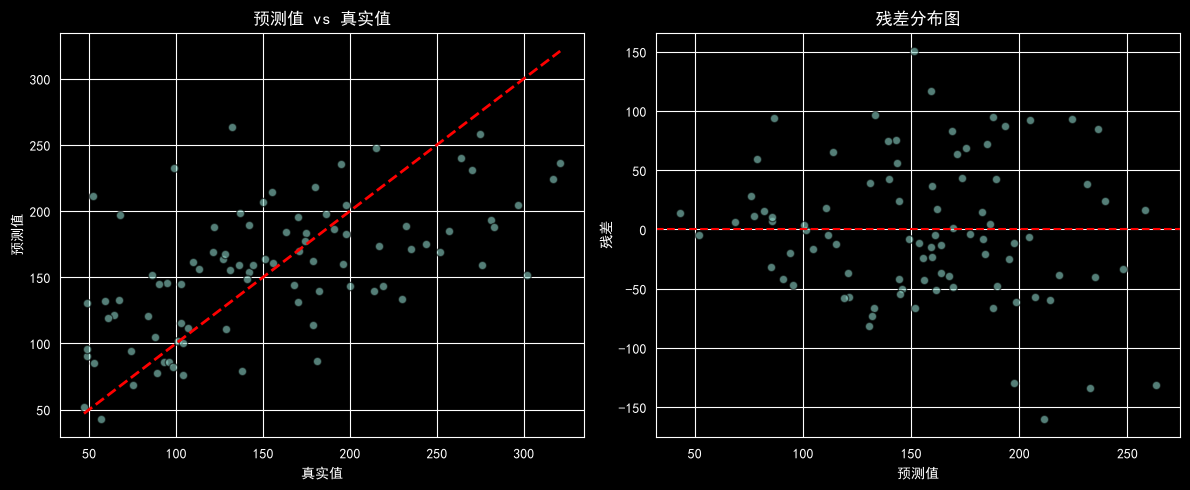

In [9]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

residuals = y_test - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 左图：预测值 vs 真实值
ax1.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('真实值')
ax1.set_ylabel('预测值')
ax1.set_title('预测值 vs 真实值')

# 右图：残差分布
ax2.scatter(y_pred, residuals, alpha=0.6, edgecolors='k')
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('预测值')
ax2.set_ylabel('残差')
ax2.set_title('残差分布图')

plt.tight_layout()
plt.savefig('ridge_pred_residual.png', dpi=200, bbox_inches='tight')
plt.show()